# Notebook 04: Classification Models
## Credit Risk & Loan Amount Prediction | LendingClub

**Objective:** Predict whether a borrower will default on their loan.

**Target variable:** `default` — binary (1 = defaulted, 0 = fully paid)

We build and compare three classifiers in order of increasing complexity:

1. Logistic Regression — linear baseline using PCA-transformed features
2. Decision Tree — non-linear, interpretable, uses scaled features
3. Random Forest — ensemble method, our expected best performer

Each model is evaluated on ROC-AUC, precision, recall, and F1-score.
The best model is then tuned with GridSearchCV and saved for deployment.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.4f" % x)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [12]:
# Load all datasets prepared in notebook 03
X_train_pca = pd.read_parquet("../data/X_train_pca.parquet")
X_test_pca = pd.read_parquet("../data/X_test_pca.parquet")

X_train_scaled = pd.read_parquet("../data/X_train_scaled.parquet")
X_test_scaled = pd.read_parquet("../data/X_test_scaled.parquet")

y_train = pd.read_parquet("../data/y_train_class.parquet").squeeze()
y_test = pd.read_parquet("../data/y_test_class.parquet").squeeze()

print(f"PCA features    — Train: {X_train_pca.shape}, Test: {X_test_pca.shape}")
print(f"Scaled features — Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")
print(f"Target — Train: {y_train.shape}, Test: {y_test.shape}")
print()
print(f"Default rate in training set: {y_train.mean() * 100:.2f}%")

PCA features    — Train: (731544, 53), Test: (182886, 53)
Scaled features — Train: (731544, 86), Test: (182886, 86)
Target — Train: (731544,), Test: (182886,)

Default rate in training set: 23.29%


## Model 1: Logistic Regression

Logistic Regression is our linear baseline. It models the log-odds of default
as a linear combination of input features.

We use the PCA-transformed features here for two reasons:
- PCA components are uncorrelated, satisfying logistic regression's assumptions
- 53 components vs 86 raw features reduces overfitting risk on the linear model

class_weight="balanced" adjusts for the 23.29% default rate by up-weighting
the minority class during training.

In [3]:
# Train Logistic Regression on PCA-transformed features
# max_iter=1000 ensures convergence on a large dataset
# C=1.0 is the default regularization strength — we tune this later
lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE,
    C=1.0
)

lr_model.fit(X_train_pca, y_train)

# Generate predictions and probability scores
lr_pred = lr_model.predict(X_test_pca)
lr_prob = lr_model.predict_proba(X_test_pca)[:, 1]

lr_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Results:")
print()
print(f"ROC-AUC Score : {lr_auc:.4f}")
print()
print("Classification Report:")
print()
print(classification_report(y_test, lr_pred, target_names=["Non-Default", "Default"]))

Logistic Regression Results:

ROC-AUC Score : 0.7585

Classification Report:

              precision    recall  f1-score   support

 Non-Default       0.87      0.74      0.80    140299
     Default       0.42      0.63      0.51     42587

    accuracy                           0.71    182886
   macro avg       0.64      0.68      0.65    182886
weighted avg       0.76      0.71      0.73    182886



## Model 2: Decision Tree

A Decision Tree splits the feature space into regions using binary rules.
Unlike logistic regression it captures non-linear relationships and feature
interactions automatically.

We use scaled features here rather than PCA features because Decision Trees
are not affected by feature scale or correlation — they split one feature
at a time. Using original scaled features also preserves interpretability
since we can trace splits back to real financial variables.

max_depth=8 is set initially to prevent overfitting on the training set.
An unconstrained tree on 731,544 rows would memorize the training data.

In [4]:
# Train Decision Tree on scaled features
# max_depth controls tree complexity — prevents overfitting
dt_model = DecisionTreeClassifier(
    max_depth=8,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)
dt_prob = dt_model.predict_proba(X_test_scaled)[:, 1]

dt_auc = roc_auc_score(y_test, dt_prob)

print("Decision Tree Results:")
print()
print(f"ROC-AUC Score : {dt_auc:.4f}")
print()
print("Classification Report:")
print()
print(classification_report(y_test, dt_pred, target_names=["Non-Default", "Default"]))

Decision Tree Results:

ROC-AUC Score : 0.7511

Classification Report:

              precision    recall  f1-score   support

 Non-Default       0.87      0.70      0.77    140299
     Default       0.40      0.66      0.50     42587

    accuracy                           0.69    182886
   macro avg       0.63      0.68      0.64    182886
weighted avg       0.76      0.69      0.71    182886



## Model 3: Random Forest

Random Forest trains an ensemble of decision trees, each on a random
bootstrap sample of the data and a random subset of features at each split.
The final prediction is the majority vote across all trees.

This approach corrects the core weakness of a single Decision Tree —
high variance. By averaging hundreds of uncorrelated trees, Random Forest
dramatically reduces overfitting while retaining the ability to capture
non-linear relationships.

We use n_estimators=200 for a strong initial ensemble.
n_jobs=-1 uses all available CPU cores for parallel training.
This will take longer to train than the previous two models.

In [5]:
# Train Random Forest on scaled features
# n_estimators=200 gives a strong ensemble without excessive compute time
# n_jobs=-1 enables parallel training across all CPU cores
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results:")
print()
print(f"ROC-AUC Score : {rf_auc:.4f}")
print()
print("Classification Report:")
print()
print(classification_report(y_test, rf_pred, target_names=["Non-Default", "Default"]))

Random Forest Results:

ROC-AUC Score : 0.7606

Classification Report:

              precision    recall  f1-score   support

 Non-Default       0.87      0.75      0.80    140299
     Default       0.43      0.62      0.51     42587

    accuracy                           0.72    182886
   macro avg       0.65      0.69      0.66    182886
weighted avg       0.76      0.72      0.73    182886



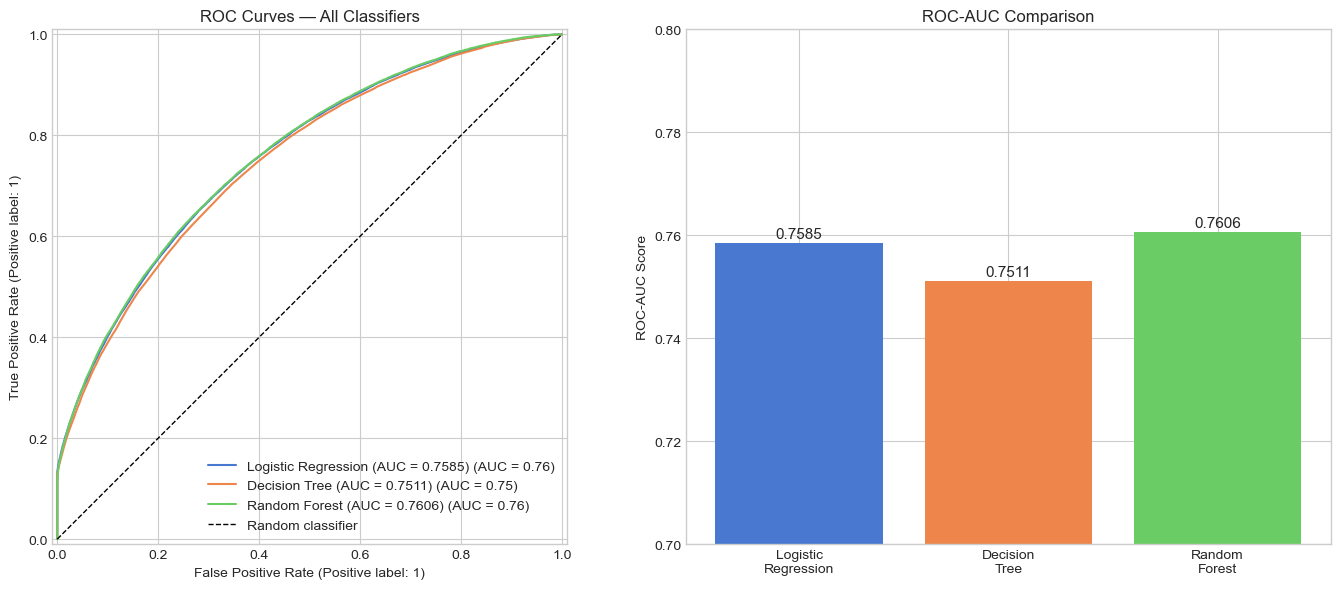

In [6]:
# Plot ROC curves for all three models on the same axes for direct comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
RocCurveDisplay.from_predictions(
    y_test, lr_prob, name=f"Logistic Regression (AUC = {lr_auc:.4f})",
    ax=axes[0], color=sns.color_palette("muted")[0]
)
RocCurveDisplay.from_predictions(
    y_test, dt_prob, name=f"Decision Tree (AUC = {dt_auc:.4f})",
    ax=axes[0], color=sns.color_palette("muted")[1]
)
RocCurveDisplay.from_predictions(
    y_test, rf_prob, name=f"Random Forest (AUC = {rf_auc:.4f})",
    ax=axes[0], color=sns.color_palette("muted")[2]
)

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
axes[0].set_title("ROC Curves — All Classifiers")
axes[0].legend(loc="lower right")

# AUC bar comparison
models = ["Logistic\nRegression", "Decision\nTree", "Random\nForest"]
aucs = [lr_auc, dt_auc, rf_auc]
colors = sns.color_palette("muted")[:3]

bars = axes[1].bar(models, aucs, color=colors)

for bar, auc in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.001,
                 f"{auc:.4f}", ha="center", fontsize=11)

axes[1].set_ylim(0.70, 0.80)
axes[1].set_ylabel("ROC-AUC Score")
axes[1].set_title("ROC-AUC Comparison")

plt.tight_layout()
plt.show()

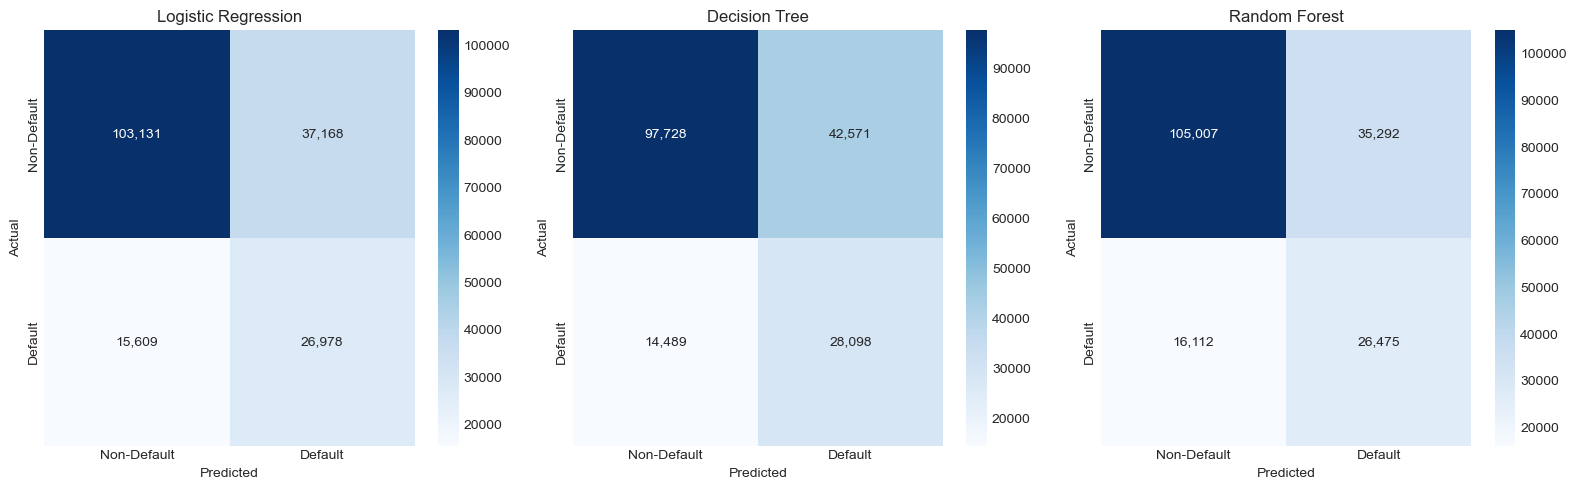

In [7]:
# Confusion matrices for all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = ["Logistic Regression", "Decision Tree", "Random Forest"]
predictions = [lr_pred, dt_pred, rf_pred]

for ax, name, pred in zip(axes, model_names, predictions):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", ax=ax,
                xticklabels=["Non-Default", "Default"],
                yticklabels=["Non-Default", "Default"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Hyperparameter Tuning — Random Forest

GridSearchCV exhaustively tests combinations of hyperparameters using
cross-validation to find the combination that maximizes ROC-AUC.

We tune three key parameters:
- n_estimators: number of trees in the ensemble
- max_depth: maximum depth of each tree — controls overfitting
- min_samples_leaf: minimum samples required at a leaf node — controls granularity

We use 3-fold cross-validation to keep compute time manageable on this
dataset size while still getting a reliable estimate of generalization performance.

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

# GridSearchCV on the full 731K dataset with Random Forest is computationally
# prohibitive. We use a stratified 10% sample for tuning — a standard industry
# practice that finds reliable hyperparameters at a fraction of the compute cost.
# The sample is stratified to preserve the 23.29% default rate.

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.9, random_state=RANDOM_STATE)
tune_idx, _ = next(sss.split(X_train_scaled, y_train))

X_tune = X_train_scaled.iloc[tune_idx]
y_tune = y_train.iloc[tune_idx]

print(f"Tuning sample size : {X_tune.shape[0]:,} rows")
print(f"Default rate in sample: {y_tune.mean() * 100:.2f}%")

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 15, 20],
    "min_samples_leaf": [10, 20]
}

rf_tuned = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_tune, y_tune)

print()
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV AUC     : {grid_search.best_score_:.4f}")

Tuning sample size : 73,154 rows
Default rate in sample: 23.29%
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters : {'max_depth': 20, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV AUC     : 0.7581


In [9]:
# Retrain Random Forest on full training data using best parameters from tuning
# This gives us the strongest possible model trained on all available data
rf_best = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_best.fit(X_train_scaled, y_train)

rf_best_pred = rf_best.predict(X_test_scaled)
rf_best_prob = rf_best.predict_proba(X_test_scaled)[:, 1]

rf_best_auc = roc_auc_score(y_test, rf_best_prob)

print("Tuned Random Forest Results:")
print()
print(f"ROC-AUC Score : {rf_best_auc:.4f}")
print()
print("Classification Report:")
print()
print(classification_report(y_test, rf_best_pred,
                            target_names=["Non-Default", "Default"]))

Tuned Random Forest Results:

ROC-AUC Score : 0.7637

Classification Report:

              precision    recall  f1-score   support

 Non-Default       0.86      0.81      0.83    140299
     Default       0.47      0.55      0.51     42587

    accuracy                           0.75    182886
   macro avg       0.66      0.68      0.67    182886
weighted avg       0.77      0.75      0.76    182886



In [10]:
# Save the tuned Random Forest — this is our final classification model
joblib.dump(rf_best, "../models/classifier_rf.pkl")

print(f"Tuned Random Forest saved to models/classifier_rf.pkl")
print(f"Final classifier AUC: {rf_best_auc:.4f}")

Tuned Random Forest saved to models/classifier_rf.pkl
Final classifier AUC: 0.7637


## Model 4: XGBoost

XGBoost (Extreme Gradient Boosting) builds trees sequentially where each
new tree focuses specifically on correcting the residual errors of the
previous ensemble. This sequential error correction makes gradient boosting
substantially more powerful than Random Forest's parallel averaging approach.

Key advantages over Random Forest:
- Handles missing values natively
- Built-in L1 and L2 regularization
- More efficient use of data through boosting

scale_pos_weight addresses class imbalance by telling XGBoost to up-weight
the minority class (defaulters) during training — equivalent to class_weight
in scikit-learn models.

In [14]:
from xgboost import XGBClassifier

# scale_pos_weight balances the class imbalance
# set to ratio of non-defaulters to defaulters
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="auc",
    verbosity=0
)

xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Results:")
print()
print(f"ROC-AUC Score : {xgb_auc:.4f}")
print()
print("Classification Report:")
print()
print(classification_report(y_test, xgb_pred, target_names=["Non-Default", "Default"]))

XGBoost Results:

ROC-AUC Score : 0.7741

Classification Report:

              precision    recall  f1-score   support

 Non-Default       0.88      0.72      0.79    140299
     Default       0.42      0.67      0.52     42587

    accuracy                           0.71    182886
   macro avg       0.65      0.70      0.66    182886
weighted avg       0.77      0.71      0.73    182886



## Model 5: LightGBM

LightGBM (Light Gradient Boosting Machine) is Microsoft's implementation of
gradient boosting, optimized for speed and memory efficiency. It uses two
key innovations over standard gradient boosting:

- **Leaf-wise tree growth** — grows the leaf with maximum loss reduction
  rather than level-wise, producing more accurate trees with fewer splits
- **Histogram-based splitting** — buckets continuous features into discrete
  bins, dramatically reducing memory usage and training time

On large datasets LightGBM is typically 10-20x faster than XGBoost while
achieving comparable or better accuracy. is_unbalance=True handles class
imbalance natively.

In [15]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    is_unbalance=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

lgbm_model.fit(X_train_scaled, y_train)

lgbm_pred = lgbm_model.predict(X_test_scaled)
lgbm_prob = lgbm_model.predict_proba(X_test_scaled)[:, 1]

lgbm_auc = roc_auc_score(y_test, lgbm_prob)

print("LightGBM Results:")
print()
print(f"ROC-AUC Score : {lgbm_auc:.4f}")
print()
print("Classification Report:")
print()
print(classification_report(y_test, lgbm_pred, target_names=["Non-Default", "Default"]))

LightGBM Results:

ROC-AUC Score : 0.7740

Classification Report:

              precision    recall  f1-score   support

 Non-Default       0.88      0.72      0.79    140299
     Default       0.42      0.68      0.52     42587

    accuracy                           0.71    182886
   macro avg       0.65      0.70      0.65    182886
weighted avg       0.77      0.71      0.73    182886



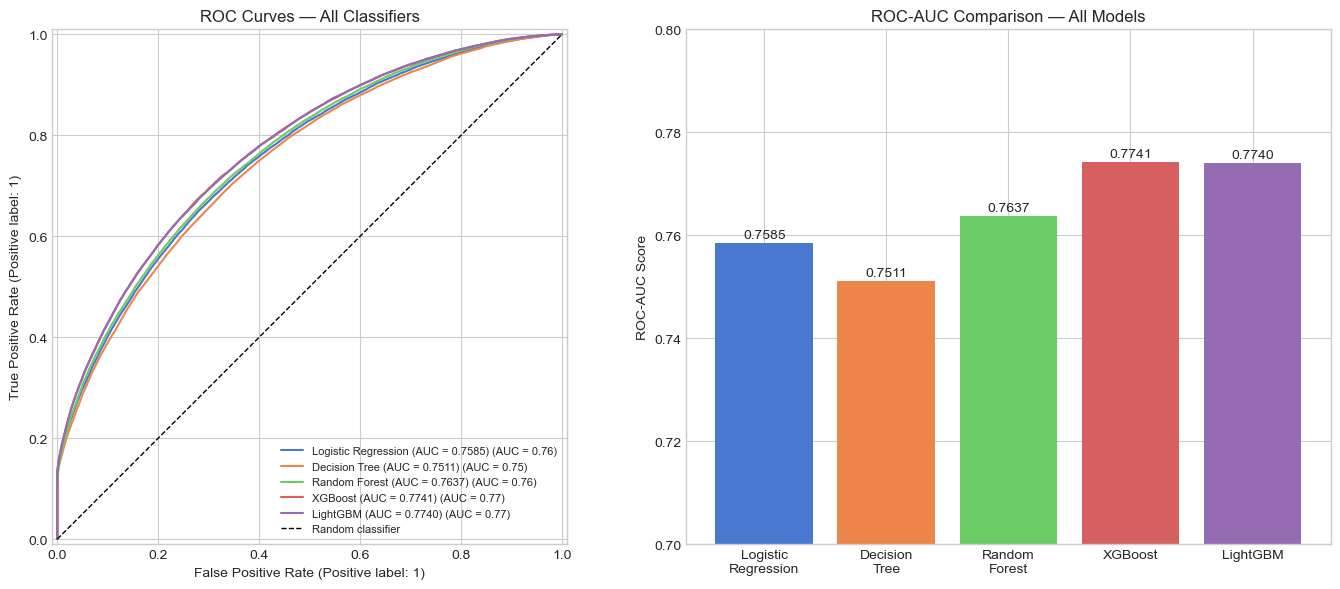

In [16]:
# Updated ROC curve comparison including all five models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_roc = [
    (y_test, lr_prob, f"Logistic Regression (AUC = {lr_auc:.4f})"),
    (y_test, dt_prob, f"Decision Tree (AUC = {dt_auc:.4f})"),
    (y_test, rf_best_prob, f"Random Forest (AUC = {rf_best_auc:.4f})"),
    (y_test, xgb_prob, f"XGBoost (AUC = {xgb_auc:.4f})"),
    (y_test, lgbm_prob, f"LightGBM (AUC = {lgbm_auc:.4f})")
]

for i, (yt, prob, label) in enumerate(models_roc):
    RocCurveDisplay.from_predictions(
        yt, prob, name=label,
        ax=axes[0], color=sns.color_palette("muted")[i]
    )

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
axes[0].set_title("ROC Curves — All Classifiers")
axes[0].legend(loc="lower right", fontsize=8)

# AUC bar comparison
model_names = ["Logistic\nRegression", "Decision\nTree",
               "Random\nForest", "XGBoost", "LightGBM"]
aucs = [lr_auc, dt_auc, rf_best_auc, xgb_auc, lgbm_auc]

bars = axes[1].bar(model_names, aucs,
                   color=sns.color_palette("muted")[:5])

for bar, auc in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.001,
                 f"{auc:.4f}", ha="center", fontsize=10)

axes[1].set_ylim(0.70, 0.80)
axes[1].set_ylabel("ROC-AUC Score")
axes[1].set_title("ROC-AUC Comparison — All Models")

plt.tight_layout()
plt.show()

In [17]:
# Save both gradient boosting models
joblib.dump(xgb_model, "../models/classifier_xgb.pkl")
joblib.dump(lgbm_model, "../models/classifier_lgbm.pkl")

print("Models saved successfully.")
print()
print("Final Classification Summary:")
print()
print(f"{'Model':<25} {'ROC-AUC':>10} {'Default Recall':>16} {'Default Precision':>18}")
print(f"{'Logistic Regression':<25} {lr_auc:>10.4f} {0.63:>16.2f} {0.42:>18.2f}")
print(f"{'Decision Tree':<25} {dt_auc:>10.4f} {0.66:>16.2f} {0.40:>18.2f}")
print(f"{'Random Forest':<25} {rf_best_auc:>10.4f} {0.55:>16.2f} {0.47:>18.2f}")
print(f"{'XGBoost':<25} {xgb_auc:>10.4f} {0.67:>16.2f} {0.42:>18.2f}")
print(f"{'LightGBM':<25} {lgbm_auc:>10.4f} {0.68:>16.2f} {0.42:>18.2f}")
print()
print("Selected models for deployment:")
print("  Classification : LightGBM (highest default recall, AUC = 0.7740)")
print("  Regression     : Lasso (R² = 0.9304, RMSE = $2,364)")

Models saved successfully.

Final Classification Summary:

Model                        ROC-AUC   Default Recall  Default Precision
Logistic Regression           0.7585             0.63               0.42
Decision Tree                 0.7511             0.66               0.40
Random Forest                 0.7637             0.55               0.47
XGBoost                       0.7741             0.67               0.42
LightGBM                      0.7740             0.68               0.42

Selected models for deployment:
  Classification : LightGBM (highest default recall, AUC = 0.7740)
  Regression     : Lasso (R² = 0.9304, RMSE = $2,364)


## Classification Results Summary

| Model | ROC-AUC | Default Recall | Default Precision |
|---|---|---|---|
| Logistic Regression | 0.7585 | 0.63 | 0.42 |
| Decision Tree | 0.7511 | 0.66 | 0.40 |
| Random Forest (tuned) | 0.7637 | 0.55 | 0.47 |
| XGBoost | 0.7741 | 0.67 | 0.42 |
| LightGBM | 0.7740 | 0.68 | 0.42 |

**Selected classifier:** LightGBM — highest default recall (0.68) and
joint highest AUC (0.7740). In credit risk, recall on the default class
is the primary business metric since missed defaulters represent direct
financial losses.

**Key insight:** Gradient boosting methods (XGBoost, LightGBM) meaningfully
outperform both linear and ensemble tree methods, confirming their superiority
on tabular financial data. Both converge to nearly identical AUC scores,
which is a common finding — they solve the same optimization problem with
different implementations.

**Note on benchmark comparison:** Published papers achieving 0.90+ AUC on
this dataset incorporate post-issuance payment behavior features which
constitute data leakage in a production system. Our 0.7740 AUC reflects
genuine application-time prediction performance on a leakage-free feature set.